# Validation TitanTPP Notebook

- `mark = log10 order class`, `value = residual regression` 구조로 데이터를 재구성하기
- RMTPP regression baseline과 TitanTPP regression 모델을 같은 조건으로 학습하기
- validation loss 기반으로 학습 상태를 비교하기
- validation 샘플 한 건에 대해 다음 이벤트의 분포를 `mark / dt / qty` 관점에서 시각화하기

In [ ]:
from pathlib import Path
import sys

SERVER_PROJECT_ROOT = Path('~/workspace/paper_research').expanduser().resolve()
if str(SERVER_PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(SERVER_PROJECT_ROOT))

from utils.notebook_bootstrap import bootstrap_notebook

PROJECT_ROOT, DIR = bootstrap_notebook(preferred_root=SERVER_PROJECT_ROOT)


In [ ]:
from pathlib import Path
import random
import sys

import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import torch
from IPython.display import display

from models.RMTPPs.config import RMTPPConfig
from models.Titan import TitanConfig
from utils.magnitude_pipeline import build_magnitude_marked_df
from utils.training import (
    TrainingConfig,
    make_week_lookback_loaders,
    train_rmtpp,
    train_titantpp,
)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print('PROJECT_ROOT =', PROJECT_ROOT)
print('DEVICE =', DEVICE)


## 1. Raw Data Load

먼저 원본 parquet를 읽고, 필요하면 일부 part만 골라서 빠르게 실험할 수 있게 합니다.

In [7]:
PARQUET_PATH = PROJECT_ROOT / 'sample_data' / 'intermittent_df.parquet'

# Set PART_LIMIT to an integer for a quick smoke test.
# Leave it as None when you want to train on the full table.
PART_LIMIT = None

raw_df = pl.read_parquet(PARQUET_PATH)
if PART_LIMIT is not None:
    selected_parts = raw_df.select('oper_part_no').unique().head(PART_LIMIT)['oper_part_no'].to_list()
    raw_df = raw_df.filter(pl.col('oper_part_no').is_in(selected_parts))

print('raw rows =', raw_df.height)
print('unique parts =', raw_df.select('oper_part_no').n_unique())
display(raw_df.head())

raw rows = 6830468
unique parts = 23387


demand_dt,demand_qty,seq,oper_part_no
i64,f64,u32,str
201811,2.0,1,"""0001-1002"""
201812,0.0,2,"""0001-1002"""
201813,0.0,3,"""0001-1002"""
201814,0.0,4,"""0001-1002"""
201815,0.0,5,"""0001-1002"""


## 2. Magnitude-Factorised Label Build

`mark`를 기존 quantile bin이 아니라 `floor(log10(demand_qty))` 기반 오더 클래스로 구성.
그리고 `scale_residual = log10(qty) - mark`를 regression target으로 함께 생성.

In [8]:
marked_df, meta = build_magnitude_marked_df(raw_df)

print('suggested max_order =', meta['max_order'])
print('num_marks (including PAD) =', meta['num_marks'])

print('[Raw order distribution]')
display(meta['raw_distribution'])

print('[Marked distribution after merge/cap]')
display(meta['marked_distribution'])

print('[Training table preview]')
display(
    marked_df.select([
        'oper_part_no',
        'demand_dt',
        'seq',
        'delta_t',
        'demand_qty',
        'log10_qty',
        'scale_residual',
        'mark',
    ]).head(10)
)

suggested max_order = 3
num_marks (including PAD) = 5
[Raw order distribution]


raw_order,len,ratio,cum_ratio
i32,u32,f64,f64
0,215127,0.885705,0.885705
1,26117,0.107527,0.993231
2,1540,0.00634,0.999572
3,104,0.000428,1.0


[Marked distribution after merge/cap]


mark,len
i32,u32
0,215127
1,26117
2,1540
3,104


[Training table preview]


oper_part_no,demand_dt,seq,delta_t,demand_qty,log10_qty,scale_residual,mark
str,i64,u32,i32,f64,f64,f64,i32
"""0001-1002""",201811,1,0,2.0,0.30103,0.30103,0
"""0001-1002""",201902,44,43,1.0,0.0,0.0,0
"""0001-1002""",202309,260,216,1.0,0.0,0.0,0
"""0001-1002""",202312,263,3,1.0,0.0,0.0,0
"""0001-1002""",202609,416,153,1.0,0.0,0.0,0
"""0001-1002""",202612,419,3,1.0,0.0,0.0,0
"""0011-2-1-04""",201803,1,0,10.0,1.0,0.0,1
"""0011-2-1-04""",202102,157,156,10.0,1.0,0.0,1
"""0011-2-1-04""",202104,159,2,10.0,1.0,0.0,1


In [9]:
marked_df.select('demand_qty').describe()

statistic,demand_qty
str,f64
"""count""",242888.0
"""null_count""",0.0
"""mean""",6.76686
"""std""",54.420996
"""min""",1.0
"""25%""",1.0
"""50%""",2.0
"""75%""",4.0
"""max""",5000.0


## 3. Training Configuration

같은 데이터와 같은 validation split 위에서 RMTPP regression baseline과 TitanTPP regression 모델을 비교할 수 있도록 설정을 고정.

In [10]:
training_config = TrainingConfig(
    lookback=52,
    max_seq_len=64,
    batch_size=256,
    lr=3e-4,
    epochs=15,
    val_ratio=0.2,
    device=DEVICE,
    lambda_value=1.0,
    lambda_dt=1.0,
    grad_clip=1.0,
)

# RMTPP is the regression baseline because the current implementation already
# includes the residual value head on top of mark/time prediction.
rmtpp_config = RMTPPConfig(
    num_marks=meta['num_marks'],
    mark_emb_dim=32,
    rnn_hidden_dim=64,
    rnn_type='gru',
    dropout=0.1,
)

# TitanTPP reuses the same output heads, but swaps the sequence backbone with
# the Titan memory encoder.
titan_config = TitanConfig(
    d_model=64,
    n_layers=2,
    n_heads=4,
    d_ff=128,
    contextual_mem_size=16,
    persistent_mem_size=16,
    dropout=0.1,
    use_lmm=True,
    mem_size=64,
    mem_topk=4,
    use_causal=True,
)

print(training_config)
print(rmtpp_config)
print(titan_config)

TrainingConfig(lookback=52, max_seq_len=64, batch_size=256, lr=0.0003, epochs=15, val_ratio=0.2, device='cuda', lambda_value=1.0, lambda_dt=1.0, grad_clip=1.0)
RMTPPConfig(num_marks=5, mark_emb_dim=32, rnn_hidden_dim=64, rnn_type='gru', dropout=0.1, use_value_head=True, value_head_activation='sigmoid', eps=1e-08, w_min=0.001, exp_clamp=300.0)
TitanConfig(lookback=52, horizon=27, past_exo_cont_dim=0, past_exo_cat_dims=None, past_exo_cat_embed_dims=None, final_clamp_nonneg=False, exo_dim=0, d_model=64, n_layers=2, n_heads=4, d_ff=128, dropout=0.1, contextual_mem_size=16, persistent_mem_size=16, use_context_update=False, use_pos_emb=True, max_len=512, use_lmm=True, mem_size=64, mem_topk=4, use_causal=True, use_revin=True, clamp_min=0.0, clamp_max=None)


## 4. RMTPP Regression Baseline Training

이 셀은 `mark classification + residual regression + dt likelihood`를 함께 학습하는 RMTPP baseline을 실행합니다.

In [11]:
# RMTPP baseline training.
rmtpp_model, rmtpp_info = train_rmtpp(
    marked_df=marked_df,
    training_config=training_config,
    rmtpp_config=rmtpp_config,
)

print('RMTPP best_score =', rmtpp_info['best_score'])
print('RMTPP history length =', len(rmtpp_info['history']))

/home/leekwanhyeong/miniconda3/envs/ai_env/lib/python3.12/site-packages/torch/nn/modules/rnn.py:1364: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.1 and num_layers=1
  super().__init__("GRU", *args, **kwargs)


[Epoch 01] train_loss=129.43840661 | val_acc=0.91092293 val_dt_mae=31.72982523 | val_dt_rmse=42.32715282 | val_value_mae=0.23768627 | val_qty_mae=5.22672439 | val_nll_time=5.959838 val_nll_marker=0.306886 val_value_loss=0.039142 val_nll=6.266724 | total=58455 | correct=53248 | steps=206907
[Epoch 02] train_loss=5.64186759 | val_acc=0.92560089 val_dt_mae=30.86375446 | val_dt_rmse=42.92170210 | val_value_mae=0.23702547 | val_qty_mae=5.04785375 | val_nll_time=5.199500 val_nll_marker=0.266655 val_value_loss=0.038760 val_nll=5.466155 | total=58455 | correct=54106 | steps=206907
[Epoch 03] train_loss=4.97834189 | val_acc=0.92717475 val_dt_mae=31.92495984 | val_dt_rmse=44.80606881 | val_value_mae=0.23695978 | val_qty_mae=5.06908775 | val_nll_time=4.553950 val_nll_marker=0.256419 val_value_loss=0.038671 val_nll=4.810369 | total=58455 | correct=54198 | steps=206907
[Epoch 04] train_loss=4.52802919 | val_acc=0.92791036 val_dt_mae=33.39575881 | val_dt_rmse=47.00754793 | val_value_mae=0.23521218 |

## 5. TitanTPP Regression Training

이 셀은 같은 target 구조 위에서 Titan backbone을 사용하는 TitanTPP를 학습.

In [12]:
# TitanTPP training on the exact same split/labels.
titan_model, titan_info = train_titantpp(
    marked_df=marked_df,
    training_config=training_config,
    rmtpp_config=rmtpp_config,
    titan_config=titan_config,
)

print('TitanTPP best_score =', titan_info['best_score'])
print('TitanTPP history length =', len(titan_info['history']))

[Epoch 01] train_loss=39.05352642 | val_acc=0.91343769 val_dt_mae=35.51390887 | val_dt_rmse=44.74819383 | val_value_mae=0.23365888 | val_qty_mae=5.09562296 | val_nll_time=4.303062 val_nll_marker=0.265787 val_value_loss=0.038564 val_nll=4.568849 | total=58455 | correct=53395 | steps=206907
[Epoch 02] train_loss=4.14648474 | val_acc=0.92026345 val_dt_mae=39.66860882 | val_dt_rmse=49.64539379 | val_value_mae=0.23432885 | val_qty_mae=5.05536713 | val_nll_time=3.815877 val_nll_marker=0.241938 val_value_loss=0.038175 val_nll=4.057815 | total=58455 | correct=53794 | steps=206907
[Epoch 03] train_loss=3.89801835 | val_acc=0.92245317 val_dt_mae=33.36229670 | val_dt_rmse=44.03077316 | val_value_mae=0.23488294 | val_qty_mae=5.09841467 | val_nll_time=3.616619 val_nll_marker=0.236410 val_value_loss=0.038120 val_nll=3.853030 | total=58455 | correct=53922 | steps=206907
[Epoch 04] train_loss=3.73336552 | val_acc=0.92515610 val_dt_mae=30.78361510 | val_dt_rmse=41.74769420 | val_value_mae=0.23299582 | 

## 6. Loss-Based Validation Comparison

이 단계에서는 epoch별 `train_loss`, `val_nll`, `val_value_loss`, `dt_mae`, `qty_mae`, `mark_acc`를 같이 비교.
즉, 단순 accuracy만이 아니라 regression/loss 관점의 validation도 함께..

[RMTPP history]


epoch,train_loss,score,mark_acc,dt_mae,dt_rmse,value_mae,qty_mae,val_nll_time,val_nll_marker,val_nll,val_value_loss,_total,_correct,_nll_steps,model
i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str
1,129.438407,0.588398,0.910923,31.729825,42.327153,0.237686,5.226724,5.959838,0.306886,6.266724,0.039142,58455.0,53248.0,206907.0,"""RMTPP"""
2,5.641868,0.611915,0.925601,30.863754,42.921702,0.237025,5.047854,5.1995,0.266655,5.466155,0.03876,58455.0,54106.0,206907.0,"""RMTPP"""
3,4.978342,0.602856,0.927175,31.92496,44.806069,0.23696,5.069088,4.55395,0.256419,4.810369,0.038671,58455.0,54198.0,206907.0,"""RMTPP"""
4,4.528029,0.58895,0.92791,33.395759,47.007548,0.235212,5.002434,4.282074,0.251674,4.533748,0.03869,58455.0,54241.0,206907.0,"""RMTPP"""
5,4.268496,0.58486,0.931229,34.142078,49.66054,0.235863,4.948716,4.119584,0.246826,4.36641,0.03852,58455.0,54435.0,206907.0,"""RMTPP"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
11,3.68605,0.606274,0.931503,32.033616,47.158664,0.234162,4.892901,3.541777,0.240793,3.78257,0.038027,58455.0,54451.0,206907.0,"""RMTPP"""
12,3.651768,0.611128,0.937439,32.146507,48.86926,0.234022,4.846175,3.629782,0.239289,3.869071,0.038034,58455.0,54798.0,206907.0,"""RMTPP"""
13,3.64717,0.604356,0.934018,32.485378,49.202567,0.234288,4.807988,3.55719,0.239331,3.796521,0.03802,58455.0,54598.0,206907.0,"""RMTPP"""


[TitanTPP history]


epoch,train_loss,score,mark_acc,dt_mae,dt_rmse,value_mae,qty_mae,val_nll_time,val_nll_marker,val_nll,val_value_loss,_total,_correct,_nll_steps,model
i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str
1,39.053526,0.553203,0.913438,35.513909,44.748194,0.233659,5.095623,4.303062,0.265787,4.568849,0.038564,58455.0,53395.0,206907.0,"""TitanTPP"""
2,4.146485,0.518522,0.920263,39.668609,49.645394,0.234329,5.055367,3.815877,0.241938,4.057815,0.038175,58455.0,53794.0,206907.0,"""TitanTPP"""
3,3.898018,0.583732,0.922453,33.362297,44.030773,0.234883,5.098415,3.616619,0.23641,3.85303,0.03812,58455.0,53922.0,206907.0,"""TitanTPP"""
4,3.733366,0.612382,0.925156,30.783615,41.747694,0.232996,4.93752,3.516467,0.233878,3.750345,0.03795,58455.0,54080.0,206907.0,"""TitanTPP"""
5,3.630072,0.612099,0.932735,31.591711,42.006011,0.234094,4.718924,3.351506,0.232104,3.58361,0.037871,58455.0,54523.0,206907.0,"""TitanTPP"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
11,3.390094,0.619505,0.940843,31.671314,46.380643,0.234232,4.62572,3.239372,0.22863,3.468001,0.037797,58455.0,54997.0,206907.0,"""TitanTPP"""
12,3.374704,0.611107,0.94163,32.586034,48.588632,0.235653,4.662508,3.229599,0.228487,3.458086,0.037823,58455.0,55043.0,206907.0,"""TitanTPP"""
13,3.359865,0.611652,0.94175,32.546154,47.789405,0.234711,4.636915,3.198073,0.228305,3.426378,0.037793,58455.0,55050.0,206907.0,"""TitanTPP"""


[Best epochs by score / val_nll]


model,selection,epoch,score,train_loss,val_nll,val_value_loss,mark_acc,dt_mae,qty_mae
str,str,i64,f64,f64,f64,f64,f64,f64,f64
"""RMTPP""","""best_score""",2,0.611915,5.641868,5.466155,0.03876,0.925601,30.863754,5.047854
"""RMTPP""","""best_val_nll""",15,0.606542,3.607432,3.623979,0.037977,0.937559,32.622549,4.791015
"""TitanTPP""","""best_score""",7,0.630476,3.501694,3.54203,0.037871,0.939475,30.425439,4.744432
"""TitanTPP""","""best_val_nll""",15,0.612373,3.338188,3.392128,0.037847,0.940997,32.366898,4.955495


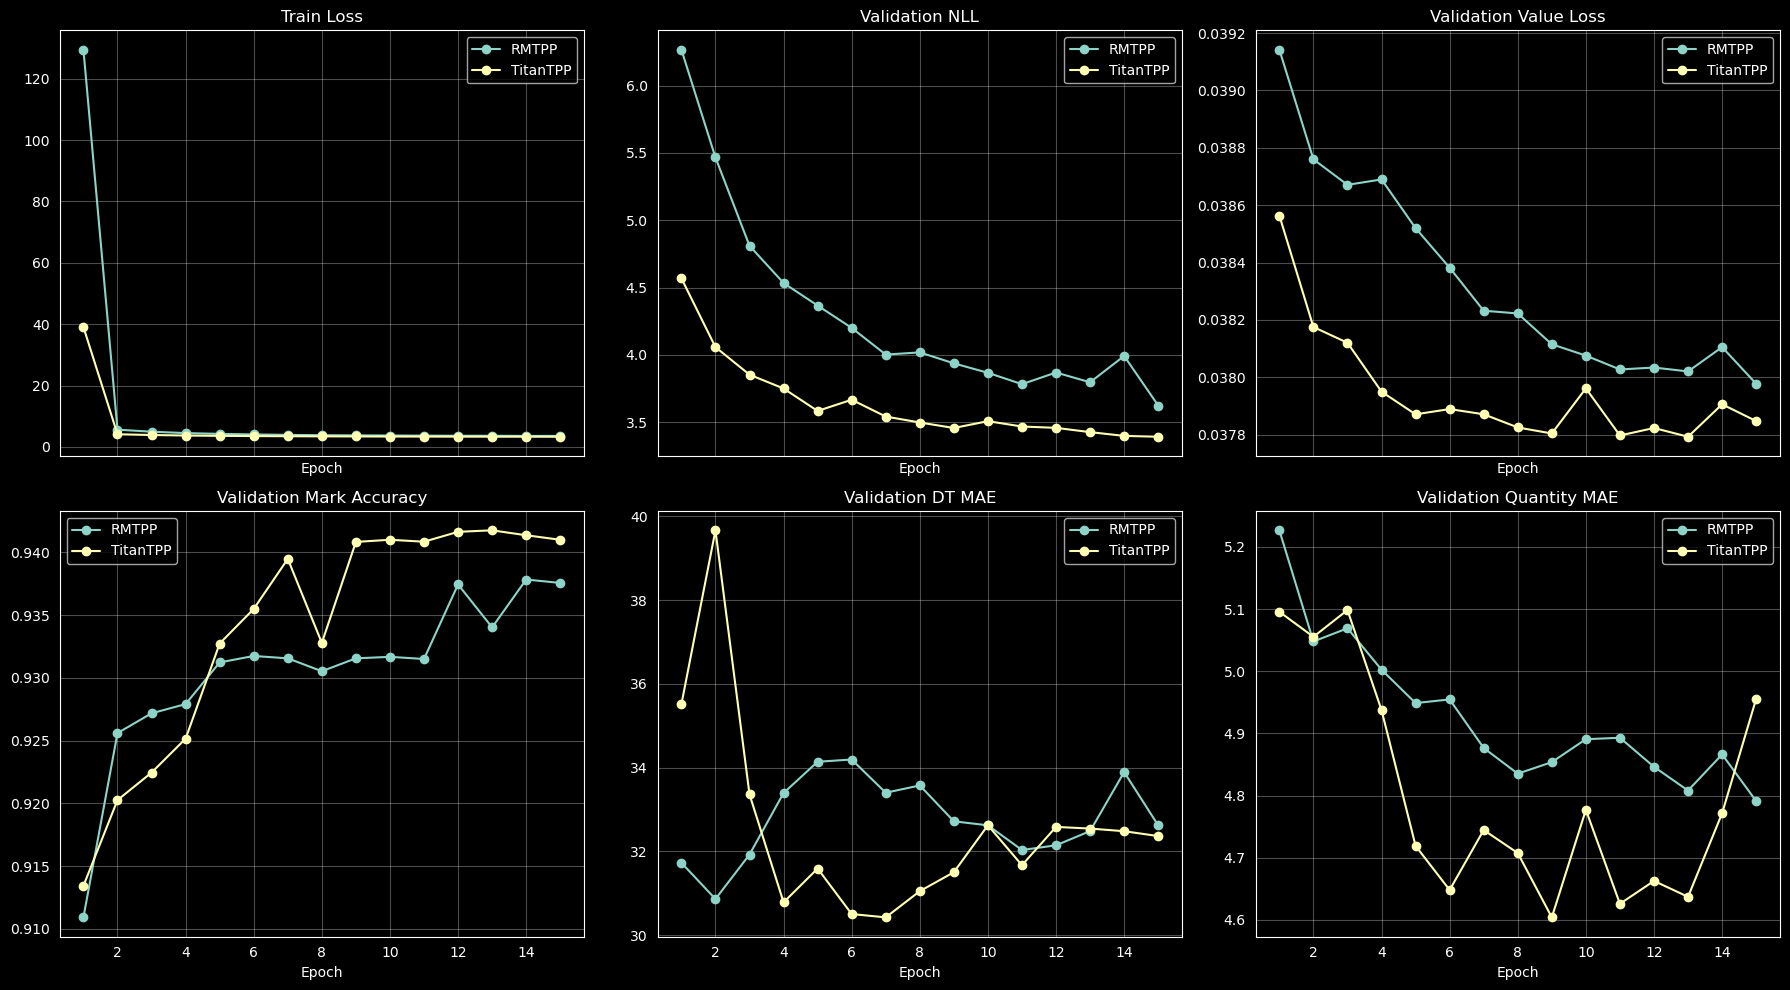

In [13]:
rmtpp_hist = pl.DataFrame(rmtpp_info['history']).with_columns(pl.lit('RMTPP').alias('model'))
titan_hist = pl.DataFrame(titan_info['history']).with_columns(pl.lit('TitanTPP').alias('model'))

print('[RMTPP history]')
display(rmtpp_hist)
print('[TitanTPP history]')
display(titan_hist)


def best_epoch(hist_df: pl.DataFrame, metric: str, descending: bool) -> pl.DataFrame:
    # Small helper to extract the best epoch under different validation criteria.
    return hist_df.sort(metric, descending=descending).head(1)


summary_table = pl.concat([
    best_epoch(rmtpp_hist, 'score', True).with_columns(pl.lit('best_score').alias('selection')),
    best_epoch(rmtpp_hist, 'val_nll', False).with_columns(pl.lit('best_val_nll').alias('selection')),
    best_epoch(titan_hist, 'score', True).with_columns(pl.lit('best_score').alias('selection')),
    best_epoch(titan_hist, 'val_nll', False).with_columns(pl.lit('best_val_nll').alias('selection')),
], how='diagonal').select([
    'model',
    'selection',
    'epoch',
    'score',
    'train_loss',
    'val_nll',
    'val_value_loss',
    'mark_acc',
    'dt_mae',
    'qty_mae',
])

print('[Best epochs by score / val_nll]')
display(summary_table)

metric_specs = [
    ('train_loss', 'Train Loss'),
    ('val_nll', 'Validation NLL'),
    ('val_value_loss', 'Validation Value Loss'),
    ('mark_acc', 'Validation Mark Accuracy'),
    ('dt_mae', 'Validation DT MAE'),
    ('qty_mae', 'Validation Quantity MAE'),
]

fig, axes = plt.subplots(2, 3, figsize=(18, 10), sharex=True)
for ax, (metric, title) in zip(axes.ravel(), metric_specs):
    for label, history in [('RMTPP', rmtpp_info['history']), ('TitanTPP', titan_info['history'])]:
        epochs = [int(row['epoch']) for row in history]
        values = [float(row[metric]) for row in history]
        ax.plot(epochs, values, marker='o', label=label)

    ax.set_title(title)
    ax.set_xlabel('Epoch')
    ax.grid(alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.show()

## 7. Validation Sample Selection and Analysis Helpers

이 단계에서는 validation set 안에서 하나의 샘플을 고르고,
그 샘플의 마지막 context로부터 **다음 이벤트 분포**를 추정하는 helper를 정의.

In [14]:
# Rebuild the validation loader with the same split logic used during training.
_, val_loader = make_week_lookback_loaders(marked_df, training_config)


def pick_validation_sample(val_loader, sample_index: int = 0, min_context_len: int = 4):
    """
    Pick one validation sample with enough valid tokens.

    sample_index counts only samples that satisfy the minimum context length.
    """
    seen = 0
    dataset = val_loader.dataset

    for marks, dts, mask, part_idx, values in val_loader:
        valid_counts = mask.sum(dim=1)
        candidate_indices = torch.where(valid_counts >= min_context_len)[0].tolist()

        for local_idx in candidate_indices:
            if seen == sample_index:
                global_part_idx = int(part_idx[local_idx].item())
                return {
                    'marks': marks[local_idx:local_idx + 1].to(DEVICE),
                    'dts': dts[local_idx:local_idx + 1].to(DEVICE),
                    'mask': mask[local_idx:local_idx + 1].to(DEVICE),
                    'values': None if values is None else values[local_idx:local_idx + 1].to(DEVICE),
                    'part_idx': global_part_idx,
                    'oper_part_no': dataset.parts[global_part_idx],
                }
            seen += 1

    raise RuntimeError('No validation sample satisfied the requested conditions.')


def sample_to_event_frame(sample: dict) -> pl.DataFrame:
    """
    Convert one padded validation sample into a readable event table.
    """
    valid_positions = torch.where(sample['mask'][0].cpu())[0].tolist()
    rows = []
    for pos in valid_positions:
        mark = int(sample['marks'][0, pos].item())
        dt = float(sample['dts'][0, pos].item())
        value = None if sample['values'] is None else float(sample['values'][0, pos].item())
        qty = None if value is None else float(10.0 ** (mark + value))
        rows.append({
            'position': pos,
            'mark': mark,
            'delta_t': dt,
            'scale_residual': value,
            'reconstructed_qty': qty,
        })
    return pl.DataFrame(rows)


def analyze_next_sample_distribution(model, sample: dict, model_name: str, n_dt_samples: int = 4000, n_mark_samples: int = 4000):
    """
    Estimate the next-event distribution from one validation sample.

    Outputs:
    - categorical mark probabilities
    - Monte Carlo dt samples from the point-process time head
    - quantity samples built from mark uncertainty + residual prediction
    """
    model.eval()

    marks = sample['marks']
    dts = sample['dts']
    mask = sample['mask']
    values = sample['values']

    valid_positions = torch.where(mask[0])[0]
    target_pos = int(valid_positions[-1].item())
    prev_pos = int(valid_positions[-2].item())

    with torch.no_grad():
        h = model.forward(marks, dts)
        h_prev = h[:, prev_pos, :]

        # Exclude the PAD class during inference.
        logits = model.mark_head(h_prev)[..., : model.cfg.num_marks - 1]
        mark_prob = torch.softmax(logits, dim=-1).squeeze(0)

        # The residual head is deterministic in the current model, so quantity
        # uncertainty mostly comes from the mark distribution.
        value_hat = model.predict_value(h_prev).squeeze(0)

        dt_samples = model.sample_next_dt(h_prev.repeat(n_dt_samples, 1)).detach().cpu().numpy()

        mark_samples = torch.multinomial(mark_prob.repeat(n_mark_samples, 1), num_samples=1).squeeze(-1)
        value_samples = value_hat.repeat(n_mark_samples)
        qty_samples = model.reconstruct_qty(mark_samples, value_samples).detach().cpu().numpy()

        qty_support = model.reconstruct_qty(
            torch.arange(mark_prob.numel(), device=marks.device),
            value_hat.repeat(mark_prob.numel()),
        ).detach().cpu().numpy()

    true_mark = int(marks[0, target_pos].item())
    true_dt = float(dts[0, target_pos].item())
    true_value = None if values is None else float(values[0, target_pos].item())
    true_qty = None if true_value is None else float(10.0 ** (true_mark + true_value))

    expected_mark = float((mark_prob * torch.arange(mark_prob.numel(), device=marks.device)).sum().item())
    expected_qty = float((mark_prob.detach().cpu().numpy() * qty_support).sum())

    summary = {
        'model': model_name,
        'oper_part_no': sample['oper_part_no'],
        'target_position': target_pos,
        'true_mark': true_mark,
        'true_dt': true_dt,
        'true_scale_residual': true_value,
        'true_qty': true_qty,
        'pred_top_mark': int(mark_prob.argmax().item()),
        'pred_expected_mark': expected_mark,
        'pred_value_residual': float(value_hat.item()),
        'pred_expected_qty': expected_qty,
        'pred_dt_mean': float(dt_samples.mean()),
        'pred_dt_q50': float(np.quantile(dt_samples, 0.5)),
        'pred_dt_q90': float(np.quantile(dt_samples, 0.9)),
    }

    return {
        'summary': summary,
        'mark_prob': mark_prob.detach().cpu().numpy(),
        'dt_samples': dt_samples,
        'qty_samples': qty_samples,
        'qty_support': qty_support,
    }

## 8. Validation Next-Sample Distribution

이제 실제 validation 샘플 하나를 고른 뒤,
RMTPP와 TitanTPP가 다음 이벤트를 어떻게 다르게 보고 있는지 `mark / dt / qty` 분포로 비교.

validation oper_part_no = T4810-26212
[Validation sample event table]


position,mark,delta_t,scale_residual,reconstructed_qty
i64,i64,f64,f64,f64
59,0,5.0,0.0,1.0
60,0,44.0,0.0,1.0
61,0,3.0,0.0,1.0
62,0,3.0,0.0,1.0
63,0,2.0,0.30103,2.0


[Next-sample summary]


model,oper_part_no,target_position,true_mark,true_dt,true_scale_residual,true_qty,pred_top_mark,pred_expected_mark,pred_value_residual,pred_expected_qty,pred_dt_mean,pred_dt_q50,pred_dt_q90
str,str,i64,i64,f64,f64,f64,i64,f64,f64,f64,f64,f64,f64
"""RMTPP""","""T4810-26212""",63,0,2.0,0.30103,2.0,0,0.032552,0.274585,2.753026,23.678711,21.881218,45.590767
"""TitanTPP""","""T4810-26212""",63,0,2.0,0.30103,2.0,0,0.008708,0.241249,1.880348,21.657057,17.944485,45.792034


[Mark probability comparison]


mark,RMTPP_prob,TitanTPP_prob,RMTPP_qty_support,TitanTPP_qty_support
i64,f64,f64,f64,f64
0,0.968729,0.991295,1.881851,1.742804
1,0.030072,0.008703,18.81851,17.428041
2,0.001117,0.000002,188.185104,174.280426
3,0.000082,3.6573e-7,1881.851074,1742.804199


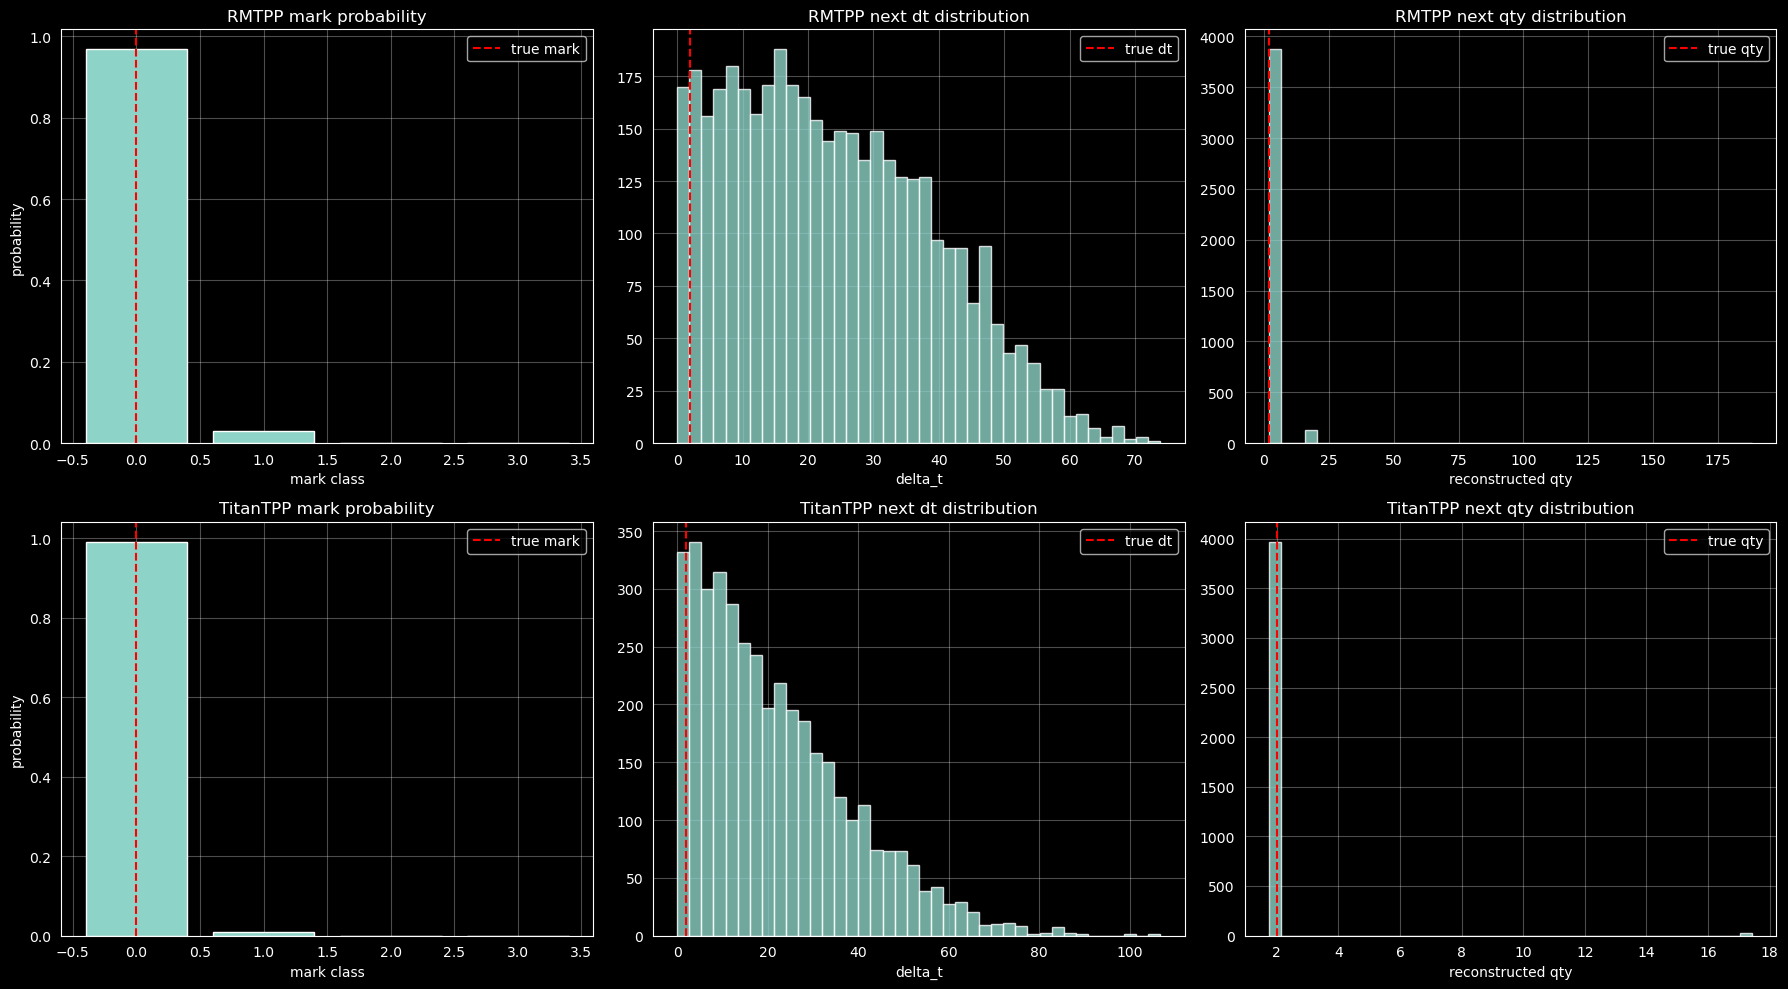

In [15]:
validation_sample = pick_validation_sample(val_loader, sample_index=2, min_context_len=5)
print('validation oper_part_no =', validation_sample['oper_part_no'])

print('[Validation sample event table]')
display(sample_to_event_frame(validation_sample))

rmtpp_dist = analyze_next_sample_distribution(rmtpp_model, validation_sample, 'RMTPP')
titan_dist = analyze_next_sample_distribution(titan_model, validation_sample, 'TitanTPP')

summary_df = pl.DataFrame([rmtpp_dist['summary'], titan_dist['summary']])
print('[Next-sample summary]')
display(summary_df)

mark_prob_df = pl.DataFrame({
    'mark': list(range(len(rmtpp_dist['mark_prob']))),
    'RMTPP_prob': rmtpp_dist['mark_prob'].tolist(),
    'TitanTPP_prob': titan_dist['mark_prob'].tolist(),
    'RMTPP_qty_support': rmtpp_dist['qty_support'].tolist(),
    'TitanTPP_qty_support': titan_dist['qty_support'].tolist(),
})
print('[Mark probability comparison]')
display(mark_prob_df)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
plot_rows = [('RMTPP', rmtpp_dist), ('TitanTPP', titan_dist)]

for row_idx, (model_name, dist) in enumerate(plot_rows):
    # Mark distribution.
    axes[row_idx, 0].bar(np.arange(len(dist['mark_prob'])), dist['mark_prob'])
    axes[row_idx, 0].axvline(dist['summary']['true_mark'], color='red', linestyle='--', label='true mark')
    axes[row_idx, 0].set_title(f'{model_name} mark probability')
    axes[row_idx, 0].set_xlabel('mark class')
    axes[row_idx, 0].set_ylabel('probability')
    axes[row_idx, 0].grid(alpha=0.3)
    axes[row_idx, 0].legend()

    # DT distribution sampled from the time head.
    axes[row_idx, 1].hist(dist['dt_samples'], bins=40, alpha=0.8)
    axes[row_idx, 1].axvline(dist['summary']['true_dt'], color='red', linestyle='--', label='true dt')
    axes[row_idx, 1].set_title(f'{model_name} next dt distribution')
    axes[row_idx, 1].set_xlabel('delta_t')
    axes[row_idx, 1].grid(alpha=0.3)
    axes[row_idx, 1].legend()

    # Quantity distribution mixes mark uncertainty with the residual prediction.
    axes[row_idx, 2].hist(dist['qty_samples'], bins=40, alpha=0.8)
    if dist['summary']['true_qty'] is not None:
        axes[row_idx, 2].axvline(dist['summary']['true_qty'], color='red', linestyle='--', label='true qty')
    axes[row_idx, 2].set_title(f'{model_name} next qty distribution')
    axes[row_idx, 2].set_xlabel('reconstructed qty')
    axes[row_idx, 2].grid(alpha=0.3)
    axes[row_idx, 2].legend()

plt.tight_layout()
plt.show()

In [ ]:
# 학습 하이퍼파라미터 튜닝 작업 및 결과 노션 정리. 후 최적 파라미터 군에서 미세튜닝
# 자재군, 제품군에 대한 메타정보를 이어줄 수 있는 방법론 고민...
# log binning을 log10 -> log2 or log4
# Data Augmentation후 -> log2 로 Binning
# or Mark 만 예측해서 Macro ACC 로 해보는 방식도 고려
# unitys